# Estudo de táxi 6.1 - Corridas de táxi em Nova York

#### Observação: Se em algum momento este notebook for encerrado, você terá que executar novamente todas as células ao reabri-lo.

#### Observação: É possível que haja diferentes resultados numéricos se o notebook for executado em diferentes ocasiões. Isto é normal. Simplesmente entregue os resultados obtidos.

# PYTHON PARA INICIANTES

Visto que esta é a versão para iniciantes, incluímos a maior parte do código para ajudá-lo no estudo.

**Primeiro, preencha suas informações de contato na célula abaixo. Depois, basta anotar as respostas às perguntas que forem feitas. Para o resto das células, basta executá-las selecionando o botão Run na parte superior do notebook**


# Informação de contato

In [1]:
# SEU NOME                 = ANDRE LUIZ PEDROSO
# SEU USUÁRIO MITX PRO    = ANDRE LUIZ PEDROSO
# SEU E-MAIL MITX PRO     = ANDRELUIZP87@GMAIL.COM
from platform import python_version
print(python_version())

3.10.12


# Configuração

Execute (Run) estas células para instalar os pacotes necessários para a realização do estudo de caso. Tenha paciência, pois isso poderá levar alguns minutos.

<h1 style="color:red;">ATENÇÃO: Podem ocorrer erros ao executar as células abaixo. Mas não se preocupe. É só executar a célula de importação de bibliotecas (duas mais abaixo) e, se aparecer a mensagem "Bibliotecas importadas com sucesso", você pode prosseguir com o estudo de caso.<h1>

In [2]:
!pip uninstall -y folium
#!pip install -q folium==0.2.1
!pip install -q folium==0.9.1
!pip uninstall -y urllib3
!pip install -q urllib3==1.25.4

Found existing installation: folium 0.14.0
Uninstalling folium-0.14.0:
  Successfully uninstalled folium-0.14.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
geemap 0.28.2 requires folium>=0.13.0, but you have folium 0.9.1 which is incompatible.
Found existing installation: urllib3 2.0.7
Uninstalling urllib3-2.0.7:
  Successfully uninstalled urllib3-2.0.7
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.5/125.5 kB 2.0 MB/s eta 0:00:00


In [3]:
!pip install -q --upgrade pip
!pip uninstall -y featuretools
#!pip install -q featuretools~=0.23.0
!pip install -q featuretools~=0.1.14
!pip uninstall -y pandas
!pip install -q pandas~=1.4.0
print('Bibliotecas instaladas com sucesso!!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.9/140.9 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 24.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2023.6.0 requires fsspec==2023.6.0, but you have fsspec 2023.10.0 which is incompatible.
Found existing installation: pandas 1.5.3
Uninstalling pandas-1.5.3:
  Successfully uninstalled pandas-1.5.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 34.0 MB/s eta 0:00:00
ERROR: pip's depend

Esperado um "error" de compatibilidade do google colab 1.0.0 com o pandas 1.4.4 no código anterior - este erro não impacta a execução do caso de uso.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#!pip uninstall -y pyyaml
# versions: 3.10, 3.11, 3.12, 3.13b1, 3.13rc1, 3.13, 4.2b1, 4.2b2, 4.2b4, 5.1b1, 5.1b3, 5.1b5, 5.1, 5.1.1, 5.1.2, 5.2b1, 5.2, 5.3b1, 5.3, 5.3.1, 5.4b1, 5.4b2, 5.4, 5.4.1, 6.0b1, 6.0, 6.0.1
#!pip install pyyaml

Esperado um "error" de compatibilidade do flax 0.7.2 - este erro não impacta a execução do caso de uso. Em alguns casos é necessario reiniciar pressionando o botão "RESTART RUNTIME" no código acima, o botão aparecerá no caso de ser necessário.

<h1>Atenção:</h1>

Agora, reinicie o ambiente de execução. Para isso, vá para:

> Ambiente de execução > _Reiniciar ambiente de execução_

na parte superior da tela. Isto irá garantir que suas alterações foram feitas com sucesso.


# Importar

Sincronize sua conta do Google. Para isso, siga o link que aparece na saída da seguinte célula uma vez executada. Copie o código que aparece na tela e insira-o na saída da célula. Assim que visualizar a mensagem: `Google Drive sincronizado com sucesso!`poderá continuar executando o restante das células.

In [6]:
from google.colab import auth
auth.authenticate_user()

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)
data_drop = drive.CreateFile({'id':'10aXz56ohVOgF2gH4yvmrvTJFY990RHZ1'})
data_drop.GetContentFile('dropoff_neighborhoods.csv')
data_pick = drive.CreateFile({'id':'1zakjpcMUZTKanSeVlPWbYhL85zn5g8zX'})
data_pick.GetContentFile('pickup_neighborhoods.csv')
data_trips = drive.CreateFile({'id':'1D4OJPulDK-Z5l4mgwuI2C1zBr4JRC-Q5'})
data_trips.GetContentFile('trips.pkl')
utils_file = drive.CreateFile({'id':'1UbV2z7L5vonCz3KFLywGs4U-p2g5gQwy'})
utils_file.GetContentFile('utils.py')

print('Google Drive sincronizado com sucesso!')

Google Drive sincronizado com sucesso!


Importe as bibliotecas necessárias para o desenvolvimento do estudo de caso.

In [7]:
import os

# Define the path to the original config.py file
config_file_path = '/usr/local/lib/python3.10/dist-packages/featuretools/config.py'

# Read the content of the original file
with open(config_file_path, 'r') as f:
    lines = f.readlines()

# Find the line to replace
for i, line in enumerate(lines):
    if 'config_dict = yaml.load(text)' in line:
        lines[i] = '        config_dict = yaml.load(text, Loader=yaml.FullLoader)\n'

# Write the modified content back to the original file
with open(config_file_path, 'w') as f:
    f.writelines(lines)

In [8]:
import featuretools as ft
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import utils
from featuretools.primitives import (Count, Day, Hour, Max, Mean, Median, Min,
                                     Minute, Month, Std, Sum, Week, Weekday,
                                     Weekend as Weekend)
from sklearn.ensemble import GradientBoostingRegressor
from utils import (compute_features, feature_importances, load_nyc_taxi_data,
                   preview)
%matplotlib inline

print('Bibliotecas importadas com suceso!')

Bibliotecas importadas com suceso!


In [9]:
# assert ft.__version__ == '0.1.19', 'Certifique-se de ter executado o comando anterior com a versão correta.'
# assert pd.__version__ == '0.20.3', 'Certifique-se de ter executado o comando anterior com a versão correta.'
# print('Versão correta das bibliotecas chave!!')

# Dados

Carregue o banco de dados de corridas de táxi em Nova York. Tenha paciência, pois isso poderá levar alguns minutos.

In [10]:
trips, pickup_neighborhoods, dropoff_neighborhoods = load_nyc_taxi_data()
print(preview(trips, 10))
print('Dados carregados com sucesso!')

       id  vendor_id     pickup_datetime    dropoff_datetime  passenger_count  \
0  514030          2 2016-04-02 00:00:00 2016-04-02 00:17:00                1   
1  514031          1 2016-04-02 00:00:00 2016-04-02 00:24:00                2   
2  514032          1 2016-04-02 00:00:00 2016-04-02 00:19:00                1   
3  514033          2 2016-04-02 00:00:00 2016-04-02 00:01:00                1   
4  514034          1 2016-04-02 00:01:00 2016-04-02 00:58:00                2   
5  514035          1 2016-04-02 00:01:00 2016-04-02 00:09:00                2   
6  514036          1 2016-04-02 00:01:00 2016-04-02 00:05:00                1   
7  514037          1 2016-04-02 00:01:00 2016-04-02 00:20:00                1   
8  514038          1 2016-04-02 00:01:00 2016-04-02 00:10:00                1   
9  514039          1 2016-04-02 00:01:00 2016-04-02 00:17:00                1   

   trip_distance  pickup_longitude  pickup_latitude  dropoff_longitude  \
0           2.46        -73.987595

Também podemos gerar alguns gráficos sobre alguns aspectos dos dados para ter uma ideia melhor de suas distribuições. Por exemplo, aqui é exibida a variável `trip_duration` (duração da corrida), a qual tentaremos prever.

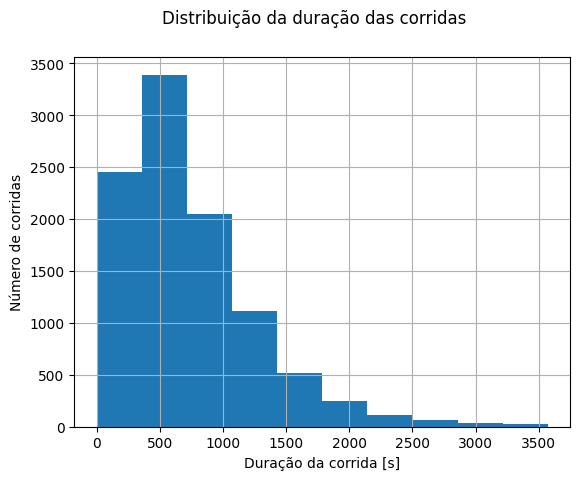

Histograma gerado com sucesso!


In [11]:
trips.trip_duration.hist()
plt.xlabel('Duração da corrida [s]')
plt.ylabel('Número de corridas')
plt.suptitle('Distribuição da duração das corridas')
plt.show()
print('Histograma gerado com sucesso!')

In [12]:
trips.shape[0]  # Mostra quantas corridas existem no banco de dados

10000

In [13]:
trips.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,trip_duration,pickup_neighborhood,dropoff_neighborhood
0,514030,2,2016-04-02 00:00:00,2016-04-02 00:17:00,1,2.46,-73.987595,40.754711,-73.959633,40.762836,1,1039,AA,K
1,514031,1,2016-04-02 00:00:00,2016-04-02 00:24:00,2,7.90,-73.924713,40.745567,-73.972763,40.793354,1,1454,L,U
2,514032,1,2016-04-02 00:00:00,2016-04-02 00:19:00,1,1.00,-73.989800,40.732994,-74.000557,40.742622,1,1168,H,Q
3,514033,2,2016-04-02 00:00:00,2016-04-02 00:01:00,1,0.02,-73.987465,40.719822,-73.987289,40.720016,2,35,AC,AC
4,514034,1,2016-04-02 00:01:00,2016-04-02 00:58:00,2,19.00,-73.790131,40.643429,-73.975594,40.779327,1,3470,G,I


<h1>PERGUNTA 1: ANÁLISE DE DADOS</h1>

**Descreva o banco de dados. Quantas corridas existem no banco de dados? Como você descreveria a distribuição da duração das corridas? Há algo mais que devemos observar? Certifique-se de que o histograma esteja visível no *notebook***.



*Escreva aqui sua resposta...*
Existem 10.000 (Dez Mil) corridas no banco de dados; sobre a distribuição é notável pelo histograma que temos
uma concentração maior de corridas com duração mais curta, podemos observar isso principalmente na
duração abaixo de 1500s. Com isso podemos pressumir que poucas corridas nesta base de dados possui uma
duração maior que 1500s.

# Entidades e relações

In [14]:
entities = {
    "trips": (trips, "id", 'pickup_datetime'),
    "pickup_neighborhoods": (pickup_neighborhoods, "neighborhood_id"),
    "dropoff_neighborhoods": (dropoff_neighborhoods, "neighborhood_id"),
}

relationships = [("pickup_neighborhoods", "neighborhood_id", "trips", "pickup_neighborhood"),
                 ("dropoff_neighborhoods", "neighborhood_id", "trips", "dropoff_neighborhood")]

print('Entidades e relações configuradas com sucesso!')

Entidades e relações configuradas com sucesso!


# Primitivas de transformação

In [15]:
trans_primitives = [Weekend]

# Tenha paciência, pois isso poderá levar alguns minutos
features = ft.dfs(entities =entities,
                  relationships=relationships,
                  target_entity="trips",
                  trans_primitives=trans_primitives,
                  agg_primitives=[],
                  ignore_variables={"trips": ["pickup_latitude", "pickup_longitude",
                                              "dropoff_latitude", "dropoff_longitude", "trip_duration"]},
                  features_only=True)

print('Primitivas de transformação configuradas com sucesso!')

Primitivas de transformação configuradas com sucesso!


Aqui estão algumas *features* que acabamos de criar:

In [16]:
print(f"Número de features: {len(features)}")
features

Número de features: 12


[<Feature: vendor_id>,
 <Feature: passenger_count>,
 <Feature: trip_distance>,
 <Feature: payment_type>,
 <Feature: pickup_neighborhood>,
 <Feature: dropoff_neighborhood>,
 <Feature: WEEKEND(pickup_datetime)>,
 <Feature: WEEKEND(dropoff_datetime)>,
 <Feature: pickup_neighborhoods.latitude>,
 <Feature: pickup_neighborhoods.longitude>,
 <Feature: dropoff_neighborhoods.latitude>,
 <Feature: dropoff_neighborhoods.longitude>]

Por fim, calculamos a matriz de *features* com as *features* mencionadas antes:

In [17]:
feature_matrix = compute_features(features, entities, relationships)
preview(feature_matrix, 5)

Elapsed: 00:00 | Remaining: ? | Progress:   0%|          | Calculated: 0/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:00 | Remaining: 00:07 | Progress:  10%|█         | Calculated: 1/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:01 | Remaining: 00:04 | Progress:  20%|██        | Calculated: 2/10 chunks

...

Elapsed: 00:05 | Remaining: 00:00 | Progress:  90%|█████████ | Calculated: 9/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:05 | Remaining: 00:00 | Progress: 100%|██████████| Calculated: 10/10 chunks
Finishing computing...


/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)
/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)


,trip_distance,pickup_neighborhood = AA,pickup_neighborhood = D,pickup_neighborhood = AC,pickup_neighborhood = AB,pickup_neighborhood = AO,pickup_neighborhood = AD,pickup_neighborhood = Q,pickup_neighborhood = AR,pickup_neighborhood = AP,...,dropoff_neighborhood = M,dropoff_neighborhood = AF,dropoff_neighborhood = T,dropoff_neighborhood = B,dropoff_neighborhood = AI,dropoff_neighborhood = AE,dropoff_neighborhood = AQ,pickup_neighborhoods.longitude,WEEKEND(dropoff_datetime),vendor_id
id,,,,,,,,,,,,,,,,,,,,,
514030,2.46,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-73.986446,True,2
514031,7.90,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-73.919159,True,1
514032,1.00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-73.991595,True,1
514033,0.02,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-73.987205,True,2
514034,19.00,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-73.785073,True,1


# Primeiro modelo

In [18]:
# Separação dos dados de treinamento e teste
X_train, y_train, X_test, y_test = utils.get_train_test_fm(feature_matrix, trips, .75)
y_train = np.log(y_train + 1)
y_test = np.log(y_test + 1)

print('Dados separados com sucesso!')

Dados separados com sucesso!


In [19]:
# O treinamento deve durar cerca de um minuto
model = GradientBoostingRegressor(verbose=True)
model.fit(X_train, y_train)
print(model.score(X_test, y_test)) # Valor R^2 da previsão

print('Fase de treinamento realizada com sucesso!')

      Iter       Train Loss   Remaining Time 
         1           0.4736            3.17s
         2           0.4148            3.02s
         3           0.3661            2.93s
         4           0.3266            2.87s
         5           0.2934            2.83s
         6           0.2665            2.79s
         7           0.2441            2.79s
         8           0.2257            2.76s
         9           0.2103            2.74s
        10           0.1973            2.74s
        20           0.1433            2.44s
        30           0.1308            2.07s
        40           0.1252            1.73s
        50           0.1212            1.42s
        60           0.1187            1.12s
        70           0.1167            0.84s
        80           0.1155            0.55s
        90           0.1143            0.28s
       100           0.1133            0.00s
0.7554602339195134
Fase de treinamento realizada com sucesso!


<h1 style="color:red;">PERGUNTA 2: PRIMEIRO MODELO</h1>

**Descreva todas as *features* que adicionamos ao modelo. Na sua opinião, elas melhoraram o desempenho em comparação a um modelo que não as possui? Por quê?**

*Escreva aqui sua resposta...*
Sim melhoram o desempenho, isso pois as features em questão em grande parte podem influenciar na duração
da corrida, fatores como: distância, área, localização e definição de periodo (semana ou final de semana) são
itens com boa influência.

# Mais primitivas de transformação

In [20]:
trans_primitives = [Minute, Hour, Day, Week, Month, Weekday, Weekend]

features = ft.dfs(entities=entities,
                  relationships=relationships,
                  target_entity="trips",
                  trans_primitives=trans_primitives,
                  agg_primitives=[],
                  ignore_variables={"trips": ["pickup_latitude", "pickup_longitude",
                                              "dropoff_latitude", "dropoff_longitude", "trip_duration"]},
                  features_only=True)

print('Primitivas de tranformação configuradas com sucesso!')

Primitivas de tranformação configuradas com sucesso!


In [21]:
print(f"Número de features: {len(features)}")
features

Número de features: 24


[<Feature: vendor_id>,
 <Feature: passenger_count>,
 <Feature: trip_distance>,
 <Feature: payment_type>,
 <Feature: pickup_neighborhood>,
 <Feature: dropoff_neighborhood>,
 <Feature: MINUTE(pickup_datetime)>,
 <Feature: MINUTE(dropoff_datetime)>,
 <Feature: HOUR(pickup_datetime)>,
 <Feature: HOUR(dropoff_datetime)>,
 <Feature: DAY(pickup_datetime)>,
 <Feature: DAY(dropoff_datetime)>,
 <Feature: WEEK(pickup_datetime)>,
 <Feature: WEEK(dropoff_datetime)>,
 <Feature: MONTH(pickup_datetime)>,
 <Feature: MONTH(dropoff_datetime)>,
 <Feature: WEEKDAY(pickup_datetime)>,
 <Feature: WEEKDAY(dropoff_datetime)>,
 <Feature: WEEKEND(pickup_datetime)>,
 <Feature: WEEKEND(dropoff_datetime)>,
 <Feature: pickup_neighborhoods.latitude>,
 <Feature: pickup_neighborhoods.longitude>,
 <Feature: dropoff_neighborhoods.latitude>,
 <Feature: dropoff_neighborhoods.longitude>]

In [22]:
feature_matrix = compute_features(features, entities, relationships)
preview(feature_matrix, 5)

Elapsed: 00:00 | Remaining: ? | Progress:   0%|          | Calculated: 0/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:00 | Remaining: 00:02 | Progress:  10%|█         | Calculated: 1/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:00 | Remaining: 00:02 | Progress:  20%|██        | Calculated: 2/10 chunks

...

Elapsed: 00:02 | Remaining: 00:00 | Progress: 100%|██████████| Calculated: 10/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 


Finishing computing...


/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)
/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)


,pickup_neighborhood = AA,pickup_neighborhood = D,pickup_neighborhood = AC,pickup_neighborhood = AB,pickup_neighborhood = AO,pickup_neighborhood = AD,pickup_neighborhood = Q,pickup_neighborhood = AR,pickup_neighborhood = AP,pickup_neighborhood = H,...,MONTH(dropoff_datetime),MINUTE(dropoff_datetime),MONTH(pickup_datetime),DAY(pickup_datetime),pickup_neighborhoods.longitude,passenger_count,WEEKEND(pickup_datetime),DAY(dropoff_datetime),MINUTE(pickup_datetime),pickup_neighborhoods.latitude
id,,,,,,,,,,,,,,,,,,,,,
514030,1,0,0,0,0,0,0,0,0,0,...,4,17,4,2,-73.986446,1,True,2,0,40.757707
514031,0,0,0,0,0,0,0,0,0,0,...,4,24,4,2,-73.919159,2,True,2,0,40.744928
514032,0,0,0,0,0,0,0,0,0,1,...,4,19,4,2,-73.991595,1,True,2,0,40.729652
514033,0,0,1,0,0,0,0,0,0,0,...,4,1,4,2,-73.987205,1,True,2,0,40.720245
514034,0,0,0,0,0,0,0,0,0,0,...,4,58,4,2,-73.785073,2,True,2,1,40.646194


In [23]:
# Separar novamente os dados
X_train, y_train, X_test, y_test = utils.get_train_test_fm(feature_matrix, trips, .75)
y_train = np.log(y_train + 1)
y_test = np.log(y_test + 1)

print('Dados separados com sucesso!')

Dados separados com sucesso!


In [24]:
# O treinamento deve durar cerca de um minuto
model = GradientBoostingRegressor(verbose=True)
model.fit(X_train, y_train)
print(model.score(X_test, y_test)) # Valor R^2 da previsão

print('Fase de treinamento realizada com sucesso!')

      Iter       Train Loss   Remaining Time 
         1           0.4736            2.34s
         2           0.4148            2.24s
         3           0.3661            2.17s
         4           0.3264            2.11s
         5           0.2930            2.11s
         6           0.2660            2.11s
         7           0.2432            2.07s
         8           0.2245            2.04s
         9           0.2090            2.06s
        10           0.1960            2.04s
        20           0.1362            1.81s
        30           0.1198            1.55s
        40           0.1124            1.31s
        50           0.1075            1.10s
        60           0.1044            0.88s
        70           0.1017            0.66s
        80           0.0999            0.44s
        90           0.0971            0.22s
       100           0.0936            0.00s
0.8012702948995593
Fase de treinamento realizada com sucesso!


<h1 style="color:red;">PERGUNTA 3: SEGUNDO MODELO</h1>

**Descreva o restante das novas *features* que acabamos de adicionar ao modelo. Como elas afetaram o desempenho? Foi preciso sacrificar um pouco do tempo de treinamento?**

*Escreva aqui sua resposta...*
Foram acrescentadas as seguintes features ao modelo, obtidas através de primitivas de transformação:
MINUTE (pickup_datetime) - retorna a parte do minuto do horário de início da corrida
MINUTE (dropoff_datetime) - retorna a parte do minuto do horário fi nal da corrida
HOUR (pickup_datetime) - retorna a parte da hora do horário de início da corrida
HOUR (dropoff_datetime) - retorna a parte da hora do horário fi nal da corrida
DAY (pickup_datetime) - retorna o número do dia referente ao horário de início da corrida
DAY (dropoff_datetime) - retorna o número do dia referente ao horário de fi nal da corrida
WEEK (pickup_datetime) - retorna a semana do ano que ocorreu o início da corrida
WEEK (dropoff_datetime) - retorna a semana do ano que ocorreu o fi nal da corrida
MONTH (pickup_datetime) - retorna o mês do início da corrida
MONTH (dropoff_datetime) - retorna o mês do fi nal da corrida
WEEKDAY (pickup_datetime) - retorna o dia da semana em que ocorreu o início da corrida
WEEKDAY (dropoff_datetime) - retorna o dia da semana em que ocorreu o fi nal da corrida
O desempenho do modelo melhorou com a entrada dessas novas features. Isso pode ser notado pelo R² que aumentou para 0.80.
Com base no Remaining time, vemos que o segundo modelo requer menos tempo de treinamento, uma vez que o Remaining time que era3.01s no primeiro modelo foi reduzido para 2.83s

# Primitivas de agregação

In [25]:
trans_primitives = [Minute, Hour, Day, Week, Month, Weekday, Weekend]
aggregation_primitives = [Count, Sum, Mean, Median, Std, Max, Min]

features = ft.dfs(entities=entities,
                  relationships=relationships,
                  target_entity="trips",
                  trans_primitives=trans_primitives,
                  agg_primitives=aggregation_primitives,
                  ignore_variables={"trips": ["pickup_latitude", "pickup_longitude",
                                              "dropoff_latitude", "dropoff_longitude", "trip_duration"]},
                  features_only=True)

print('Primitivas de agregação configuradas com sucesso!')

Primitivas de agregação configuradas com sucesso!


In [26]:
print(f"Número de features: {len(features)}")
features

Número de features: 62


[<Feature: vendor_id>,
 <Feature: passenger_count>,
 <Feature: trip_distance>,
 <Feature: payment_type>,
 <Feature: pickup_neighborhood>,
 <Feature: dropoff_neighborhood>,
 <Feature: MINUTE(pickup_datetime)>,
 <Feature: MINUTE(dropoff_datetime)>,
 <Feature: HOUR(pickup_datetime)>,
 <Feature: HOUR(dropoff_datetime)>,
 <Feature: DAY(pickup_datetime)>,
 <Feature: DAY(dropoff_datetime)>,
 <Feature: WEEK(pickup_datetime)>,
 <Feature: WEEK(dropoff_datetime)>,
 <Feature: MONTH(pickup_datetime)>,
 <Feature: MONTH(dropoff_datetime)>,
 <Feature: WEEKDAY(pickup_datetime)>,
 <Feature: WEEKDAY(dropoff_datetime)>,
 <Feature: WEEKEND(pickup_datetime)>,
 <Feature: WEEKEND(dropoff_datetime)>,
 <Feature: pickup_neighborhoods.latitude>,
 <Feature: pickup_neighborhoods.longitude>,
 <Feature: dropoff_neighborhoods.latitude>,
 <Feature: dropoff_neighborhoods.longitude>,
 <Feature: pickup_neighborhoods.COUNT(trips)>,
 <Feature: pickup_neighborhoods.SUM(trips.vendor_id)>,
 <Feature: pickup_neighborhoods.SUM(t

In [27]:
# Isto pode levar certo tempo de computação, por isso tenha paciência
feature_matrix = compute_features(features, entities, relationships)
preview(feature_matrix, 5)

Elapsed: 00:00 | Remaining: ? | Progress:   0%|          | Calculated: 0/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:00 | Remaining: 00:07 | Progress:  10%|█         | Calculated: 1/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:01 | Remaining: 00:06 | Progress:  20%|██        | Calculated: 2/10 chunks

...

Elapsed: 00:08 | Remaining: 00:01 | Progress:  90%|█████████ | Calculated: 9/10 chunks

/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  my_id_vals = pd.Series([]).append(to_append)
/usr/local/lib/python3.10/dist-packages/featuretools/entityset/entity.py:249: FutureWarning: The series.append method is deprecated and will be removed from pandas in a 

Elapsed: 00:09 | Remaining: 00:00 | Progress: 100%|██████████| Calculated: 10/10 chunks
Finishing computing...


/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)
/usr/local/lib/python3.10/dist-packages/featuretools/synthesis/encode_features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[add.get_name()] = (X[f.get_name()] == label).astype(int)


,pickup_neighborhoods.STD(trips.vendor_id),dropoff_neighborhoods.MEAN(trips.passenger_count),dropoff_neighborhoods.STD(trips.trip_distance),dropoff_neighborhoods.MAX(trips.passenger_count),payment_type,WEEKEND(dropoff_datetime),pickup_neighborhoods.STD(trips.passenger_count),dropoff_neighborhood = D,dropoff_neighborhood = AA,dropoff_neighborhood = H,...,pickup_neighborhoods.STD(trips.trip_distance),pickup_neighborhoods.latitude,pickup_neighborhoods.COUNT(trips),MONTH(dropoff_datetime),WEEKDAY(pickup_datetime),pickup_neighborhoods.MAX(trips.vendor_id),pickup_neighborhoods.SUM(trips.vendor_id),dropoff_neighborhoods.MIN(trips.trip_distance),dropoff_neighborhoods.MIN(trips.passenger_count),passenger_count
id,,,,,,,,,,,,,,,,,,,,,
514030,0.499980,1.735593,2.083190,6.0,1,True,1.220735,0,0,0,...,3.368966,40.757707,444.0,4,5,2.0,668.0,0.00,1.0,1
514031,0.495728,1.618785,2.735250,6.0,1,True,1.336028,0,0,0,...,2.757987,40.744928,46.0,4,5,2.0,66.0,0.30,1.0,2
514032,0.497628,1.723549,1.703662,6.0,1,True,1.335693,0,0,0,...,2.316361,40.729652,370.0,4,5,2.0,573.0,0.00,1.0,1
514033,0.499660,1.741135,2.740489,6.0,2,True,1.222417,0,0,0,...,2.428094,40.720245,407.0,4,5,2.0,603.0,0.00,1.0,1
514034,0.484539,1.645051,2.660020,6.0,1,True,1.377787,0,0,0,...,5.241291,40.646194,154.0,4,5,2.0,250.0,0.17,1.0,2


In [28]:
# Separar novamente os dados
X_train, y_train, X_test, y_test = utils.get_train_test_fm(feature_matrix, trips, .75)
y_train = np.log(y_train + 1)
y_test = np.log(y_test + 1)

print('Dados separados com sucesso!')

Dados separados com sucesso!


In [29]:
# O treinamento deve durar cerca de um minuto
model = GradientBoostingRegressor(verbose=True)
model.fit(X_train, y_train)
print(model.score(X_test, y_test)) # Valor R^2 da previsão

print('Fase de treinamento realizada com sucesso!')

      Iter       Train Loss   Remaining Time 
         1           0.4736            6.53s
         2           0.4148            6.06s
         3           0.3661            6.01s
         4           0.3264            6.00s
         5           0.2930            5.96s
         6           0.2660            5.90s
         7           0.2432            5.82s
         8           0.2245            5.79s
         9           0.2090            5.70s
        10           0.1960            5.63s
        20           0.1363            4.97s
        30           0.1199            4.26s
        40           0.1112            3.62s
        50           0.1061            3.01s
        60           0.1027            2.33s
        70           0.1003            1.67s
        80           0.0982            1.07s
        90           0.0959            0.52s
       100           0.0898            0.00s
0.8036386042577617
Fase de treinamento realizada com sucesso!


# Avaliação com dados de teste

In [30]:
y_pred = model.predict(X_test)
y_pred = np.exp(y_pred) - 1 # Exponencial do calculado anteriormente
print('Cálculo de y_pred realizado com sucesso!')

Cálculo de y_pred realizado com sucesso!


In [31]:
# Mostrando as 5 primeiras previsões
y_pred[:5]

array([431.26888289, 668.92177133, 653.30245515, 610.01057917,
       409.40473468])

Histograma gerado com sucesso!!


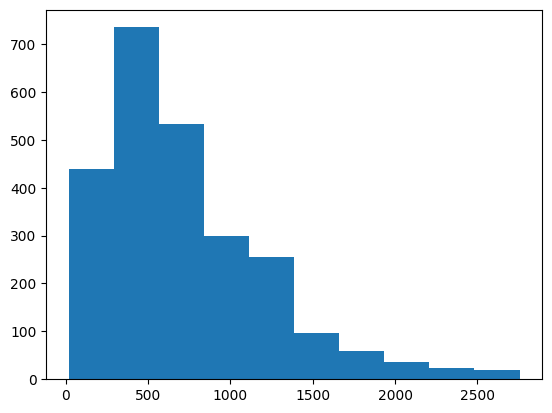

In [32]:
# Criando um histograma com todas elas
matplotlib.pyplot.hist(y_pred)

print('Histograma gerado com sucesso!!')

<h1 style="color:red;">PERGUNTA 4: PREVISÕES DO MODELO</h1>

**Analise as previsões do modelo. A distribuição dos dados previstos coincide com a distribuição dos dados reais? Que outras *features*/estratégias poderíamos usar para aprimorar ainda mais nosso modelo se tivéssemos mais tempo?**

*Escreva aqui sua resposta...*
Este último modelo apresentou desempenho levemente superior quanto comparado com o modelo anterior, valor de R² (0.8036), enquanto oanterior era 0.8012. Neste modelo, o uso de primitivas de agregação acrescentou features como média, mediana, desvio padrão, mínimo,máximo e contagem. Foi possível notar porém, que foi necessário sacrifi car um pouco do tempo de treinamento.
A distribuição dos dados previstos apresenta semelhanças com a distribuição dos dados reais. Por exemplo, a maior frequencia de duração deviagens está próxima a 500s. Porém, notam-se algumas diferenças também, por exemplo, nos dados reais, a segunda maior frequencia seencontrava em valores abaixo de 500s. Já na distribuição dos previstos, a segunda maior frequencia apresenta valores maiores do que 500s.
Poderíamos agregar outras informações à base de dados e utilizar features como condições metereológicas ou tráfego em tempo real.

# Importância das *features*

In [33]:
feature_importances(model, feature_matrix.columns, n=25)

1: Feature: trip_distance, 0.860
2: Feature: HOUR(pickup_datetime), 0.028
3: Feature: dropoff_neighborhoods.longitude, 0.027
4: Feature: dropoff_neighborhoods.latitude, 0.021
5: Feature: HOUR(dropoff_datetime), 0.012
6: Feature: MINUTE(dropoff_datetime), 0.007
7: Feature: MINUTE(pickup_datetime), 0.006
8: Feature: pickup_neighborhoods.latitude, 0.003
9: Feature: pickup_neighborhoods.SUM(trips.trip_distance), 0.003
10: Feature: dropoff_neighborhoods.COUNT(trips), 0.003
11: Feature: pickup_neighborhoods.longitude, 0.003
12: Feature: pickup_neighborhoods.COUNT(trips), 0.003
13: Feature: pickup_neighborhoods.MEDIAN(trips.trip_distance), 0.002
14: Feature: dropoff_neighborhoods.SUM(trips.trip_distance), 0.002
15: Feature: pickup_neighborhoods.MEAN(trips.trip_distance), 0.002
16: Feature: payment_type, 0.001
17: Feature: dropoff_neighborhoods.SUM(trips.passenger_count), 0.001
18: Feature: pickup_neighborhoods.MEAN(trips.passenger_count), 0.001
19: Feature: pickup_neighborhoods.STD(trips.trip

<h1 style="color:red;">PERGUNTA 5: IMPORTÂNCIA DAS FEATURES</h1>

**Analise a importância das *features* que você acabou de calcular. Elas fazem sentido? Algum valor te surpreendeu? Explique brevemente por que esses atributos são relevantes para o cálculo da variável de destino `trip_duration` (duração da corrida)**.

*Escreva aqui sua resposta...*
Sim fazem sentido, a trip_distance por exemplo é crucial com 86% de importância, o valor da feature
HOUR(pickup_datetime) me surpreendeu um pouco inicialmente mas levando em consideração que o horário
está diretamente ligado ao tráfego/horário de pico, super conversa. Estes atributos são relevantes para a
trip_duration porque trazem várias informações relativas a corrida que impactam em sua duração tais como:
distância, horário, minuto, localização dentre outros; em contra partida outras features não exerceram tanta
influência como por exemplo: payment_type (tipo de pagamento).

<hr>

Bom trabalho! Verifique a seção **Conclusão** do manual de instruções do estudo de caso.